## 1. Data Processing

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('vgsales.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


# Note: All of the "Sales" Columns are in millions.

In [4]:
df.head(67)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
62,63,Halo: Reach,X360,2010.0,Shooter,Microsoft Game Studios,7.03,1.98,0.08,0.78,9.88
63,64,Mario Kart 64,N64,1996.0,Racing,Nintendo,5.55,1.94,2.23,0.15,9.87
64,65,New Super Mario Bros. 2,3DS,2012.0,Platform,Nintendo,3.66,3.07,2.47,0.63,9.82
65,66,Halo 4,X360,2012.0,Shooter,Microsoft Game Studios,6.63,2.36,0.04,0.73,9.76


In [5]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [6]:
df[df['Year'].isna()]

df[df['Publisher'].isna()]

# Run this cell to keep it in a container; so it doesn't take up the screen!

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
1303,1305,Triple Play 99,PS,NaN,Sports,NaN,0.81,0.55,0.00,0.10,1.46
1662,1664,Shrek / Shrek 2 2-in-1 Gameboy Advance Video,GBA,2007.0,Misc,NaN,0.87,0.32,0.00,0.02,1.21
2222,2224,Bentley's Hackpack,GBA,2005.0,Misc,NaN,0.67,0.25,0.00,0.02,0.93
3159,3161,Nicktoons Collection: Game Boy Advance Video V...,GBA,2004.0,Misc,NaN,0.46,0.17,0.00,0.01,0.64
3166,3168,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004.0,Misc,NaN,0.46,0.17,0.00,0.01,0.64
3766,3768,SpongeBob SquarePants: Game Boy Advance Video ...,GBA,2004.0,Misc,NaN,0.38,0.14,0.00,0.01,0.53
4145,4147,Sonic the Hedgehog,PS3,NaN,Platform,NaN,0.00,0.48,0.00,0.00,0.48
4526,4528,The Fairly Odd Parents: Game Boy Advance Video...,GBA,2004.0,Misc,NaN,0.31,0.11,0.00,0.01,0.43
4635,4637,The Fairly Odd Parents: Game Boy Advance Video...,GBA,2004.0,Misc,NaN,0.30,0.11,0.00,0.01,0.42


In [7]:
print(271/16598)
print(58/16598)

0.016327268345583804
0.003494396915290999


Year: 271/16598 = 0.016~ --> 1.6%
Publisher: 58/16598 = 0.0035~ --> 0.35%

^^ I have decided not to fill nor drop any of the missing values.

Only two columns contain missing values. Out of 16,598 rows, the Year column has 271 missing values (1.63% of the total year data) and the Publisher column has 58 missing values (0.35% of the total Publisher data). Because the proportion of missing data is very small and limited to only two not-so-important columns, the impact on the overall analysis is negligible. Inputting values such as the mean or median year could introduce bias. Thus, the missing values will be left as they are for this analysis. I believe that the platform, genre, and sales data from the ~2% of video games which contain missing year and publisher values is invaluable for this analysis.

## 2. Univariate Analysis and Visualization

In [8]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


^^ 2.A Summary statistics

* The majority of the videgames were released between the years 2001-2011
* Only a few games are really really popular (millions of sales)

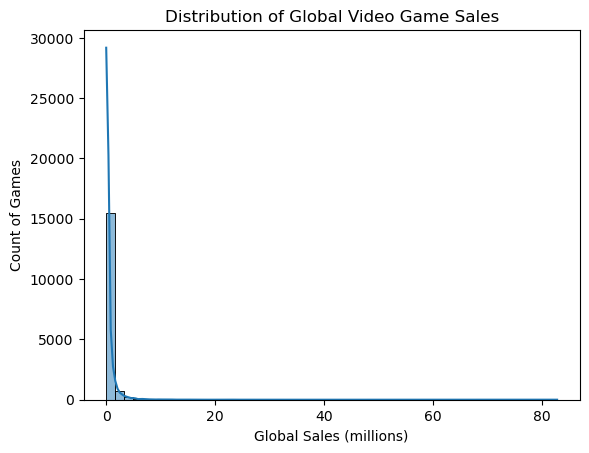

In [9]:
sns.histplot(df['Global_Sales'], bins=50, kde=True)

plt.title('Distribution of Global Video Game Sales')
plt.xlabel('Global Sales (millions)')
plt.ylabel('Count of Games')
plt.show()

In [10]:
total_games = len(df)

lt_1 = (df['Global_Sales'] < 1).sum()
gt_1 = (df['Global_Sales'] >= 1).sum()
gt_5 = (df['Global_Sales'] >= 5).sum()
gt_20 = (df['Global_Sales'] >= 20).sum()
gt_50 = (df['Global_Sales'] >= 50).sum()

print(f"< 1M sales: {lt_1} ({lt_1/total_games*100:.2f}%)")
print(f"≥ 1M sales: {gt_1} ({gt_1/total_games*100:.2f}%)")
print(f"≥ 5M sales: {gt_5} ({gt_5/total_games*100:.2f}%)")
print(f"≥ 20M sales: {gt_20} ({gt_20/total_games*100:.2f}%)")
print(f"≥ 50M sales: {gt_50} ({gt_50/total_games*100:.2f}%)")

< 1M sales: 14517 (87.46%)
≥ 1M sales: 2081 (12.54%)
≥ 5M sales: 207 (1.25%)
≥ 20M sales: 20 (0.12%)
≥ 50M sales: 1 (0.01%)


This histogram demonstrates that the majority of video games (87.46%) sell less than a million copies, meanwhile, a minority of video games (12.54%) sell more than a million copies. The data gets even more skewed as we observe that only 1.25% of the video games sell more than 5 million copies each.

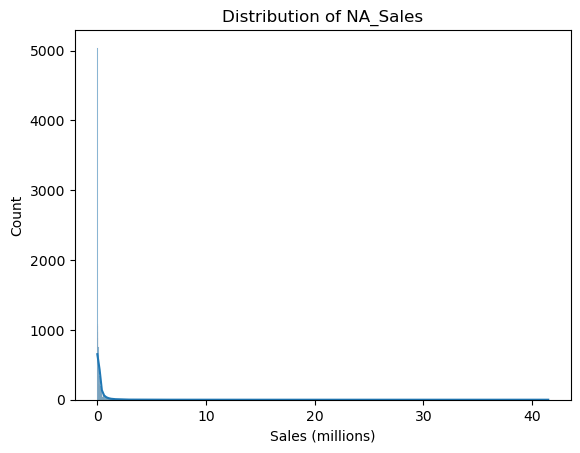

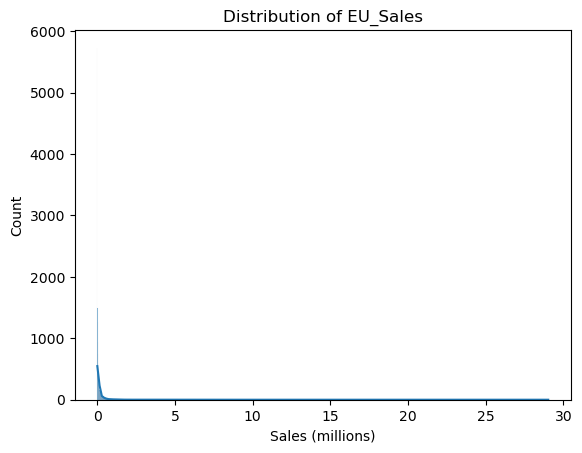

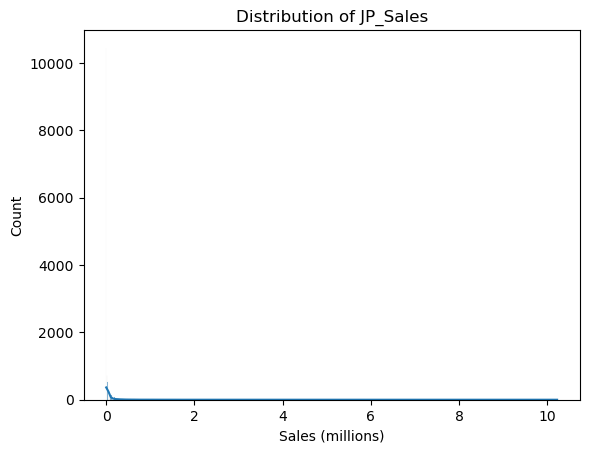

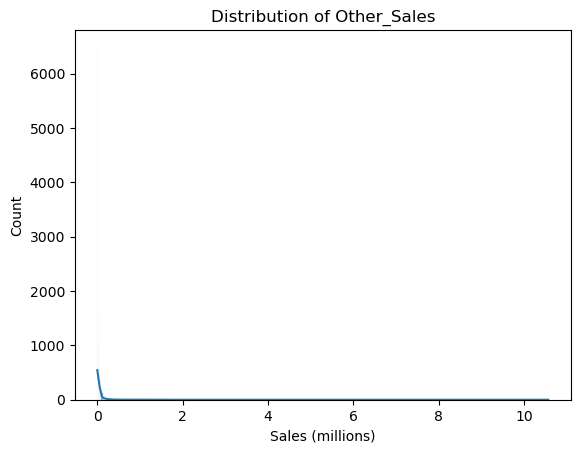

In [11]:
regions = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']

for region in regions:
    sns.histplot(df[region], kde=True)
    plt.title(f'Distribution of {region}')
    plt.xlabel('Sales (millions)')
    plt.ylabel('Count')
    plt.show()

^^ 2.B.I. Histograms to visualize the distribution of sales in different regions.

This shows us that the overwhelming majority of video games sold less than a million copies; only a minority of games sold more than a million copies.
* x-axis - Sales (millions) = the sales value in millions of copies old
* y-axis - Count = the number of games that fall within each sales range 

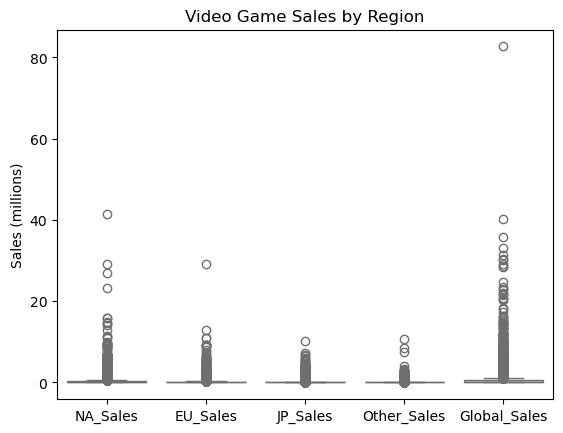

In [12]:
sns.boxplot(
    data=df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']],
    palette='pastel'
)

plt.title('Video Game Sales by Region')
plt.ylabel('Sales (millions)')
plt.show()

^^ 2.B.II. Box plots to visualize the spread of sales and identify any outliers.

This visualization demonstrates how skewed the data is; how the majority of video games sold very few copies compared to the outliers. It also shows us that North America is the largest market, followed closely by Europe, and how successful WiiSports is (the most significant outlier) compared to any other video game - with double the sales of the second most popular video game.  
* x-axis - The different sales markets in the data set
* y-axis - The number of units sold in millions 

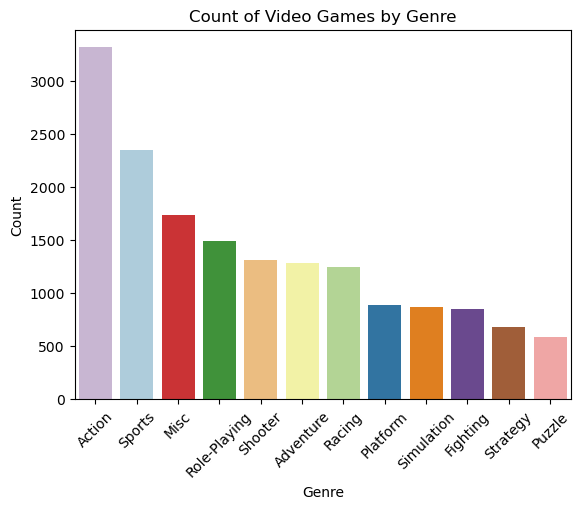

In [13]:
genre_order = df['Genre'].value_counts().index

sns.countplot(x='Genre', data=df, hue='Genre', order=genre_order, palette='Paired')

plt.title('Count of Video Games by Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

^^ 2.B.III. A bar chart to show the count of video games in each genre.

## 3. Bivariate Analysis and Visualization

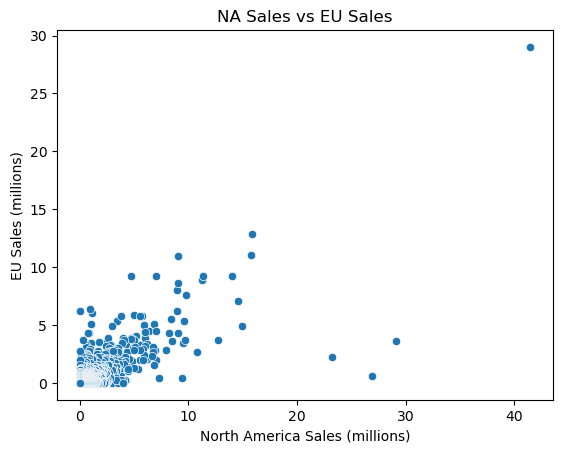

In [14]:
sns.scatterplot(x='NA_Sales', y='EU_Sales', data=df)

plt.title('NA Sales vs EU Sales')
plt.xlabel('North America Sales (millions)')
plt.ylabel('EU Sales (millions)')
plt.show()

3.A.I. A scatter plot to visualize the relationship between NA_Sales and EU_Sales.

This shows us that the video games popular in the North American market are also very popular in the European martket. It also shows us that most games sell relatively few copies, as the vast majority of points are concentred near low values.
* x-axis - the sales (millions) for North America
* y-axis - the sales (millions) for Europe

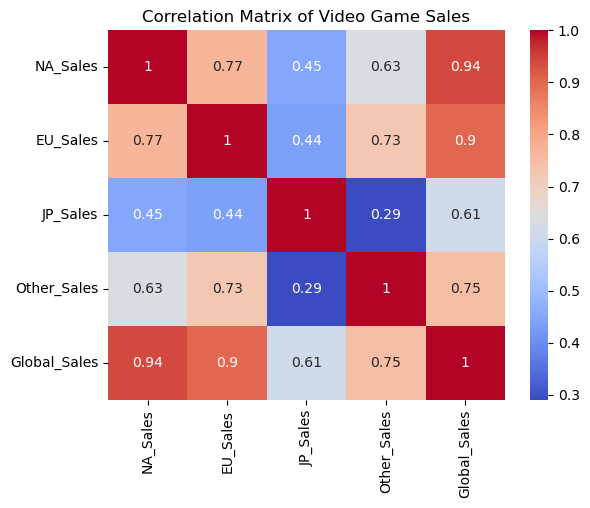

In [15]:
sales_df = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]

corr = sales_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Video Game Sales')
plt.show()

3.A.II. A correlogram visualizing the correlation matrix between the sales variables (NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales)

All correlations are positive, which means that video games that sell well in one region tend to sell well in other regions too.

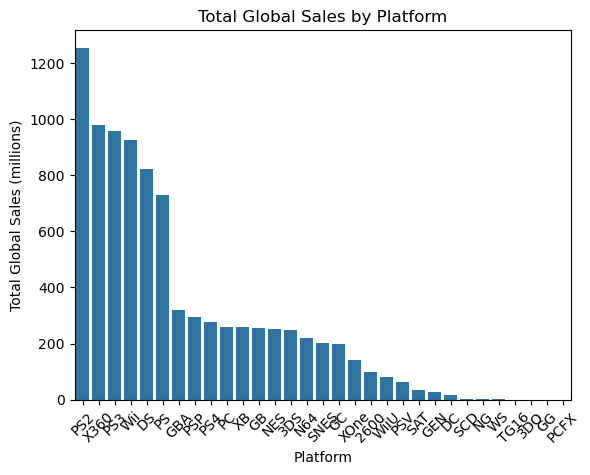

In [16]:
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False)

platform_sales = platform_sales.reset_index()

sns.barplot(x='Platform', y='Global_Sales', data=platform_sales)

plt.title('Total Global Sales by Platform')
plt.xlabel('Platform')
plt.ylabel('Total Global Sales (millions)')
plt.xticks(rotation=45)
plt.show()

^^ 3.A.III A bar chart visualizing the total sales by platform

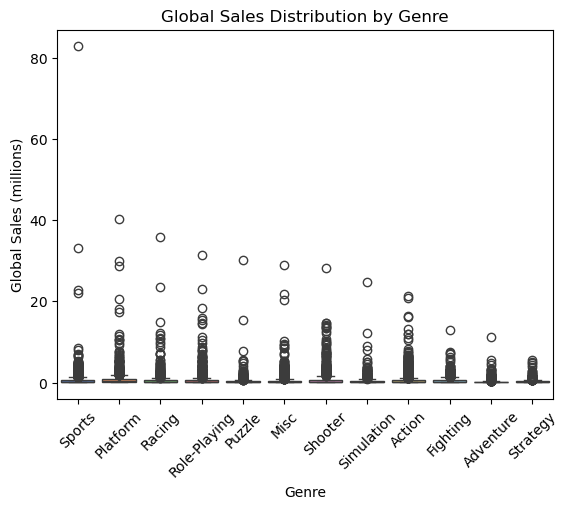

In [17]:
sns.boxplot(x='Genre', y='Global_Sales', data=df, hue='Genre', palette='muted')

plt.title('Global Sales Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Global Sales (millions)')
plt.xticks(rotation=45)
plt.show()

^^ 3.A.IV. Box plots to compare Global_Sales across different genres.

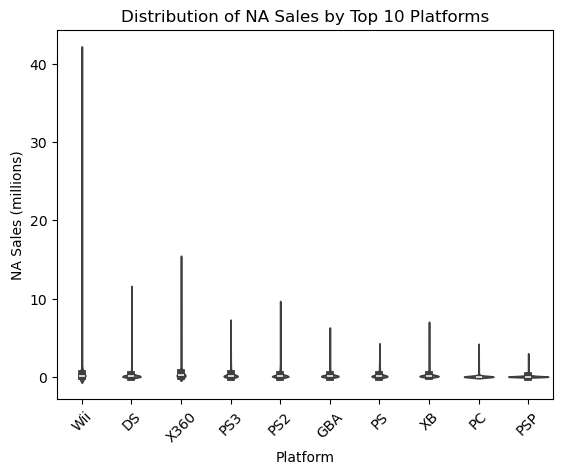

In [18]:
top10_platforms = df['Platform'].value_counts().nlargest(10).index
top_df = df[df['Platform'].isin(top10_platforms)]

sns.violinplot(x='Platform', y='NA_Sales', data=top_df)

plt.title('Distribution of NA Sales by Top 10 Platforms')
plt.xlabel('Platform')
plt.ylabel('NA Sales (millions)')
plt.xticks(rotation=45)
plt.show()

^^ 3.A.V. A violin plot to compare the distribution of NA_Sales across different platforms.

## 4. Multivariate Analysis and Visualization

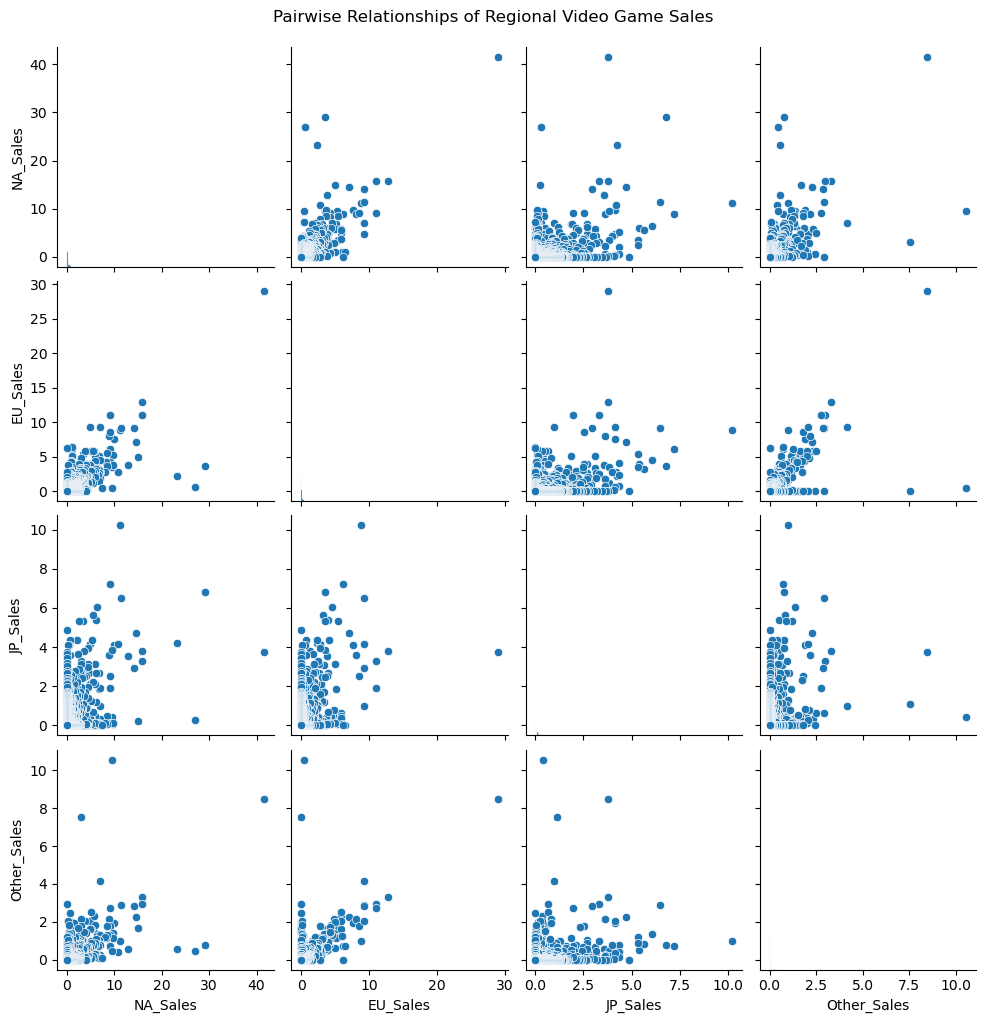

In [19]:
sns.pairplot(df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']])

plt.suptitle('Pairwise Relationships of Regional Video Game Sales', y=1.02)
plt.show()

4.A.I A pair plot for the numerical sales variables (NA_Sales, EU_Sales, JP_Sales, Other_Sales) to explore pairwise relationships.

This pair plot compares the total sales of every video game between regions. For example, a game that sold just over 10 million copies in Japan also sold just over 10 million copies in Europe.
* x-axis - the sales (millions) for a region
* y-axis - the sales (millions) for a region

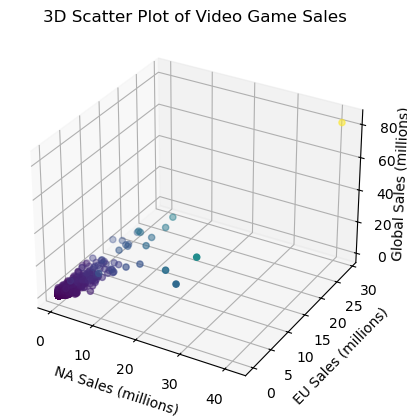

In [20]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['NA_Sales'], df['EU_Sales'], df['Global_Sales'],
           c=df['Global_Sales'], cmap='viridis')

ax.set_xlabel('NA Sales (millions)')
ax.set_ylabel('EU Sales (millions)')
ax.set_zlabel('Global Sales (millions)', labelpad=-2.5)

plt.title('3D Scatter Plot of Video Game Sales')

plt.show()

4.A.II. A 3D scatter plot of NA_Sales, EU_Sales, and Global_Sales to explore the relationship between sales in these regions.

Each point represents one video game. It shows the strong positive relationshop between North American sales and global sales. It also shows us that most games sell relatively few copies, as the vast majority of points are concentred near low values.
* x-axis - the number of video games sold in NA market
* y-axis - the number of video games sold in EU market
* z-axis - the total worldwide sales


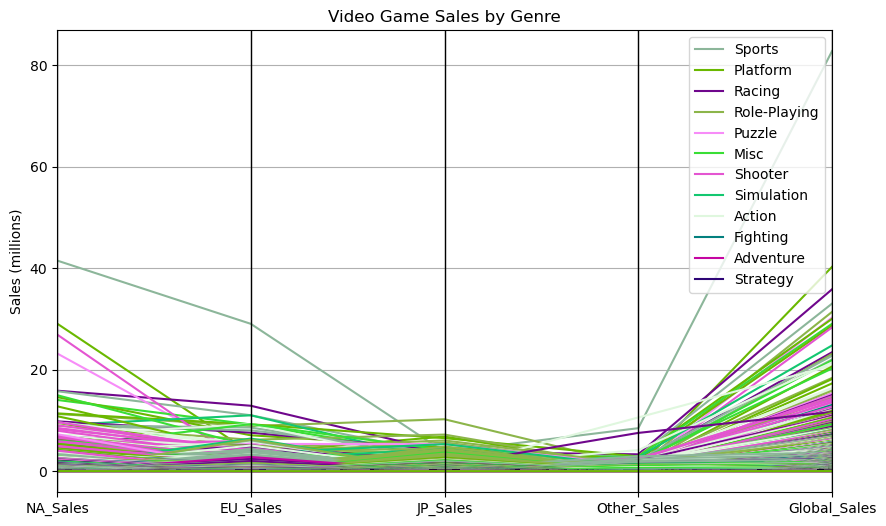

In [21]:
from pandas.plotting import parallel_coordinates

sales_df = df[['Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]

plt.figure(figsize=(10, 6))
parallel_coordinates(sales_df, 'Genre')
plt.title('Video Game Sales by Genre')
plt.ylabel('Sales (millions)')
plt.show()

4.A.III. A parallel coordinates plot to compare the sales metrics across different genres

Most games show relatively low sales across all regions, while a small number of video games have very high sales, particularly in North America and Europe. The plot suggests that Western markets contribute strongly to global sales, while Japanese sales are generally lower for most games compared to the North American and European markets.